# 🏭 A Case Study for Descripive DA: Does the Night Shift Really Produce More Defects?

> *"A manufracture company which is making some products in different shifts."*

> *"I think our Night shift produces more defective pieces than the other shifts."*

Before spending money on extra Night-shift training or supervision, We require some statisical validation using the data.


## 📥 Section 1: Load the Libraries & the Dataset

> *"Python libraries used together to handle, analyze, and visualize data"*

> *"numpy : handels math calculations much faster"*

> *"pandas: Easily filters, groups, and organize data"*

> *"matplotlib and  seaborn : For visualization "*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
url = 'https://raw.githubusercontent.com/nmrinl/dataanalytics/main/manufacturing_data.csv'
# Load the manufacturing shift-level dataset
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (600, 13)


,Date,Machine_ID,Product_Type,Shift,Operator_Experience_Years,Temperature_C,Humidity_Percent,Production_Units,Defective_Units,Downtime_Minutes,Cycle_Time_Minutes,Energy_Consumption_kWh,Raw_Material_Cost_USD
0,2025-01-01,M4,Product_B,NaN,9.5,28.5,37.5,505.0,1,42.3,6.14,154.3,2313.59
1,2025-01-01,M3,Product_A,Morning,1.5,38.7,43.4,476.0,4,44.5,5.48,191.0,1294.25
2,2025-01-01,M3,Product_B,Morning,6.0,29.3,58.6,516.0,11,16.6,6.83,220.5,2393.13
3,2025-01-02,M3,Product_A,Morning,0.0,28.5,64.9,444.0,13,23.0,6.46,202.7,1355.73
4,2025-01-02,M3,Product_B,Evening,13.9,28.7,41.0,477.0,1,0.0,5.31,126.5,2112.92


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       600 non-null    object 
 1   Machine_ID                 600 non-null    object 
 2   Product_Type               600 non-null    object 
 3   Shift                      570 non-null    object 
 4   Operator_Experience_Years  570 non-null    float64
 5   Temperature_C              564 non-null    float64
 6   Humidity_Percent           600 non-null    float64
 7   Production_Units           576 non-null    float64
 8   Defective_Units            600 non-null    int64  
 9   Downtime_Minutes           600 non-null    float64
 10  Cycle_Time_Minutes         600 non-null    float64
 11  Energy_Consumption_kWh     600 non-null    float64
 12  Raw_Material_Cost_USD      600 non-null    float64
dtypes: float64(8), int64(1), object(4)
memory usage: 6

### What's in the data?

| Column | Description |
|---|---|
| `Date` | Production date |
| `Machine_ID` | Machine used (M1–M5) |
| `Product_Type` | Product manufactured (A, B, C) |
| `Shift` | Work shift (Morning, Evening, Night) — **our hypothesis is about this column** |
| `Operator_Experience_Years` | Experience of the operator |
| `Temperature_C` / `Humidity_Percent` | Shop-floor conditions |
| `Production_Units` | Units produced in the shift |
| `Defective_Units` | Number of defective units — **our key metric** |
| `Downtime_Minutes` | Machine downtime |
| `Cycle_Time_Minutes` | Average time per unit |
| `Energy_Consumption_kWh` / `Raw_Material_Cost_USD` | Resource usage |


## 🕳️ Section 2: Checking for Missing Values (and Fixing Them)

Before trusting any statistic, we need to know if the data has gaps — especially in `Shift` and `Defective_Units`, since our whole hypothesis depends on comparing shifts fairly.

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

In [ ]:
missing_summary = pd.DataFrame({'Missing_Count': missing_count, 'Missing_Percent': missing_percent})
missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

,Missing_Count,Missing_Percent
Temperature_C,36,6.0
Shift,30,5.0
Operator_Experience_Years,30,5.0
Production_Units,24,4.0


In [ ]:
#1)  Get the table of missing value in incresing order, based on misising_percentage




### Visualizing

In [ ]:
cols_with_missing = missing_summary[missing_summary['Missing_Count'] > 0].index
cols_with_missing

Index(['Shift', 'Operator_Experience_Years', 'Temperature_C',
       'Production_Units'],
      dtype='object')

In [ ]:
missing_summary.loc[cols_with_missing,['Missing_Percent']]

,Missing_Percent
Shift,5.0
Operator_Experience_Years,5.0
Temperature_C,6.0
Production_Units,4.0


In [ ]:
# missing_summary.loc[['Shift', 'Operator_Experience_Years', 'Temperature_C',
#        'Production_Units'],['Missing_Percent']]

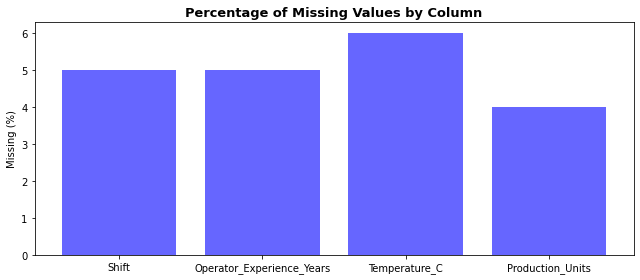

In [ ]:
cols_with_missing = missing_summary[missing_summary['Missing_Percent'] > 0].index

plt.figure(figsize=(9,4))
plt.bar(cols_with_missing, missing_summary.loc[cols_with_missing, 'Missing_Percent'], color='blue',alpha=0.6)
plt.title('Percentage of Missing Values by Column', fontsize=13, fontweight='bold')
plt.ylabel('Missing (%)')
plt.tight_layout()
plt.show()


In [ ]:
#2)  Missing count on should be in y_axis and change color also


## Imputation strategy

| Column type | Strategy | Why |
|---|---|---|
| Categorical (`Shift`) | **Mode** | Fill with the most frequent category |
| Numeric, roughly symmetric (`Temperature_C`) | **Mean** | Preserves the average |
| Numeric, skewed / has outliers (`Operator_Experience_Years`, `Production_Units`) | **Median** | Robust to extreme values |

In [ ]:
df_raw = df.copy()  # keep the original (with gaps) for reference

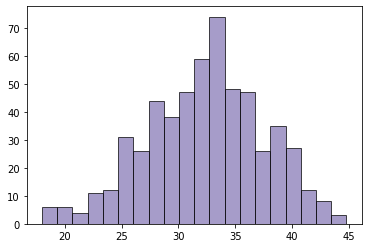

In [ ]:
plt.hist( df_raw['Temperature_C'], bins=20,color='#8172B2',edgecolor='black',alpha=0.7 ) #checking for data distribution
plt.show()

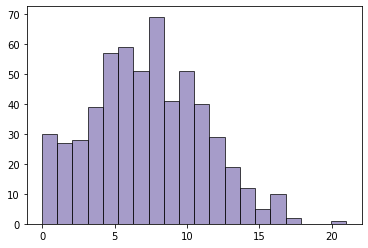

In [ ]:
plt.hist( df_raw['Operator_Experience_Years'], bins=20,color='#8172B2',edgecolor='black',alpha=0.7)
plt.show()

In [ ]:
# 3) checks the distibution of downtime_minutes



In [ ]:

# Categorical -> mode
df['Shift'] = df['Shift'].fillna(df['Shift'].mode()[0])

# Roughly symmetric numeric -> mean
df['Temperature_C'] = df['Temperature_C'].fillna(df['Temperature_C'].mean())

# Skewed / outlier-prone numeric -> median
df['Operator_Experience_Years'] = df['Operator_Experience_Years'].fillna(df['Operator_Experience_Years'].median())
df['Production_Units'] = df['Production_Units'].fillna(df['Production_Units'].median())

print("Total missing values remaining:", df.isnull().sum().sum())


Total missing values remaining: 0


🔍 **Good news:** `Defective_Units` (and `Shift`, after imputation) has no missing values feeding into our hypothesis test — the defect counts and shift labels we're about to compare are complete and trustworthy.

## 📊 Section 3: Describing the Data — Mean, Median, Mode, Correlation & Covariance

In [ ]:
df[['Defective_Units']].mean()

Defective_Units    5.761667
dtype: float64

In [ ]:
# Defect rate normalizes for how many units were actually produced that shift
df['Defect_Rate_Percent'] = (df['Defective_Units'] / df['Production_Units']) * 100
df[['Defective_Units', 'Defect_Rate_Percent']].describe()


,Defective_Units,Defect_Rate_Percent
count,600.000000,600.000000
mean,5.761667,1.240475
std,4.249505,0.914585
min,1.000000,0.190476
25%,2.000000,0.423060
50%,5.000000,1.070664
75%,9.000000,1.872810
max,20.000000,4.201681


### 3.1 Central tendency & spread — overall

In [ ]:
print(f"Mean Defect Rate    : {df['Defect_Rate_Percent'].mean():.2f}%")
print(f"Median Defect Rate  : {df['Defect_Rate_Percent'].median():.2f}%")
print(f"Mode Defective_Units: {df['Defective_Units'].mode()[0]}")
print(f"Std Dev             : {df['Defect_Rate_Percent'].std():.2f}%")


Mean Defect Rate    : 1.24%
Median Defect Rate  : 1.07%
Mode Defective_Units: 1
Std Dev             : 0.91%


### 3.2 Central tendency & spread — by Shift (our first real clue)

In [ ]:
df.groupby('Shift')['Defective_Units'].agg(['mean']).round(2)

,mean
Shift,
Evening,5.44
Morning,6.03
Night,5.67


In [ ]:
shift_stats = df.groupby('Shift')['Defective_Units'].agg(['mean', 'median', 'std', 'count']).round(2)
shift_stats.sort_values('mean', ascending=False)

,mean,median,std,count
Shift,,,,
Morning,6.03,5.0,4.34,277
Night,5.67,5.0,4.37,135
Evening,5.44,4.0,4.02,188


In [ ]:
shift_stats = df.groupby('Shift')['Defect_Rate_Percent'].agg(['mean', 'median', 'std', 'count']).round(2)
shift_stats.sort_values('mean', ascending=False)


,mean,median,std,count
Shift,,,,
Morning,1.27,1.09,0.91,277
Night,1.27,1.07,0.98,135
Evening,1.18,0.93,0.87,188


### 3.3 Visualizing the distribution — Histogram & Box Plot

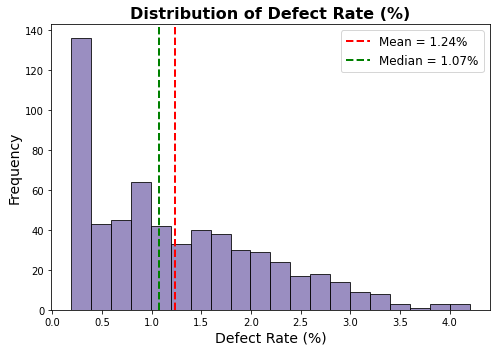

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist( df['Defect_Rate_Percent'],bins=20, color='#8172B2',edgecolor='black',alpha=0.8)

plt.axvline( df['Defect_Rate_Percent'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean = {df['Defect_Rate_Percent'].mean():.2f}%")

plt.axvline(df['Defect_Rate_Percent'].median(),color='green', linestyle='--',linewidth=2,label=f"Median = {df['Defect_Rate_Percent'].median():.2f}%")

plt.title("Distribution of Defect Rate (%)", fontsize=16, fontweight='bold')
plt.xlabel("Defect Rate (%)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# tells the distribution of defect rate, very few shifts has major (more the 3% ) defect rates.

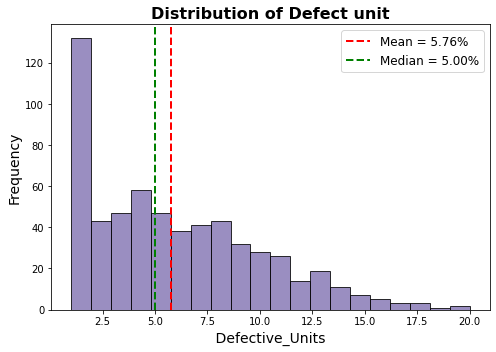

In [ ]:
plt.figure(figsize=(7, 5))

plt.hist( df['Defective_Units'],bins=20, color='#8172B2',edgecolor='black',alpha=0.8)

plt.axvline( df['Defective_Units'].mean(),color='red',linestyle='--',linewidth=2,label=f"Mean = {df['Defective_Units'].mean():.2f}%")

plt.axvline(df['Defective_Units'].median(),color='green', linestyle='--',linewidth=2,label=f"Median = {df['Defective_Units'].median():.2f}%")

plt.title("Distribution of Defect unit", fontsize=16, fontweight='bold')
plt.xlabel(" Defective_Units ", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

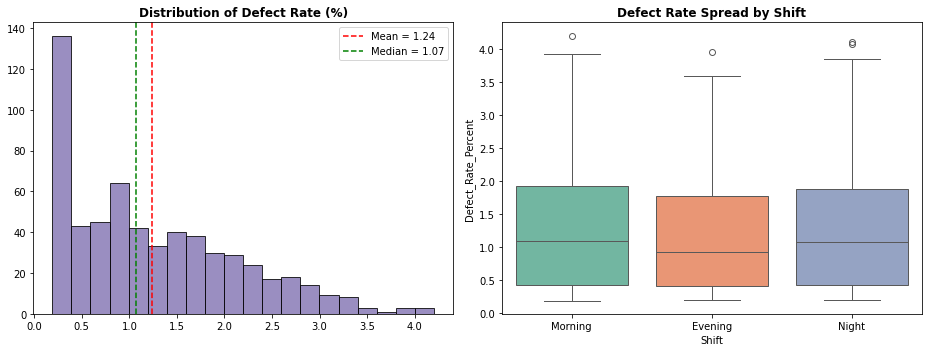

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['Defect_Rate_Percent'], bins=20, color='#8172B2', edgecolor='black', alpha=0.8)
axes[0].axvline(df['Defect_Rate_Percent'].mean(), color='red', linestyle='--', label=f"Mean = {df['Defect_Rate_Percent'].mean():.2f}")
axes[0].axvline(df['Defect_Rate_Percent'].median(), color='green', linestyle='--', label=f"Median = {df['Defect_Rate_Percent'].median():.2f}")
axes[0].set_title('Distribution of Defect Rate (%)', fontweight='bold')
axes[0].legend()

sns.boxplot(data=df, x='Shift', y='Defect_Rate_Percent', hue='Shift', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Defect Rate Spread by Shift', fontweight='bold')

plt.tight_layout()
plt.show()


The box plot is our first hint at *consistency*: even if two shifts have similar averages, one might have a much wider spread (less predictable quality).

***if Night shift has a taller box than Morning and Evening, it means Night isn't just "worse on average" — it's also less reliable***

### 3.4 Correlation & Covariance — what else moves with defects?

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()

cov_value = df['Temperature_C'].cov(df['Defective_Units'])
corr_value = df['Temperature_C'].corr(df['Defective_Units'])
print(f"Covariance(Temperature, Defective_Units)  = {cov_value:.3f}")
print(f"Correlation(Temperature, Defective_Units) = {corr_value:.3f}")


Covariance(Temperature, Defective_Units)  = 8.550
Correlation(Temperature, Defective_Units) = 0.402


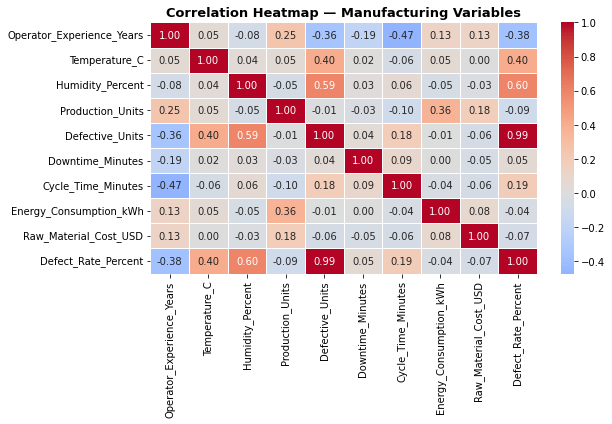

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Manufacturing Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


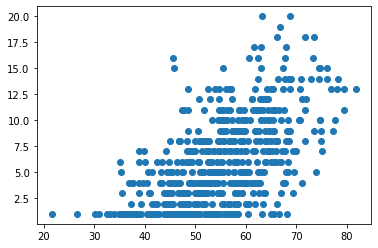

In [ ]:
plt.scatter((df['Humidity_Percent']),df['Defective_Units'])

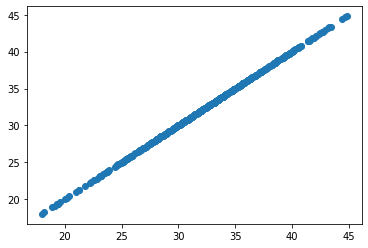

In [ ]:
plt.scatter(df['Temperature_C'],(df['Temperature_C']))

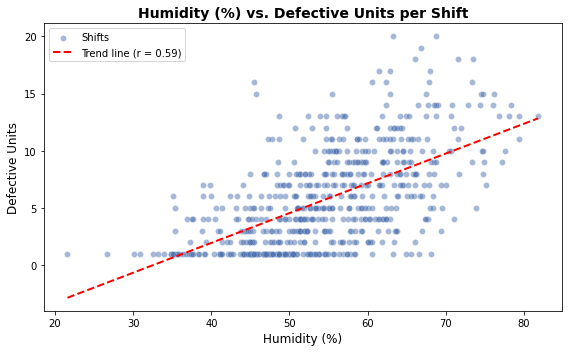

Correlation(Humidity_Percent, Defective_Units) = 0.595


In [ ]:
humidity_corr = df['Humidity_Percent'].corr(df['Defective_Units'])

# Trend line (best-fit straight line through the points)
slope, intercept = np.polyfit(df['Humidity_Percent'], df['Defective_Units'], 1)
trend_x = np.linspace(df['Humidity_Percent'].min(), df['Humidity_Percent'].max(), 100)
trend_y = slope * trend_x + intercept

plt.figure(figsize=(8, 5))
plt.scatter(df['Humidity_Percent'], df['Defective_Units'], alpha=0.5, color='#4C72B0', edgecolor='white', linewidth=0.3, label='Shifts')
plt.plot(trend_x, trend_y, color='red', linewidth=2, linestyle='--', label=f'Trend line (r = {humidity_corr:.2f})')

plt.title('Humidity (%) vs. Defective Units per Shift', fontsize=14, fontweight='bold')
plt.xlabel('Humidity (%)', fontsize=12)
plt.ylabel('Defective Units', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Correlation(Humidity_Percent, Defective_Units) = {humidity_corr:.3f}")

## 📈 Section 4: Visualizing the Hypothesis — Bar, Pie & Line

 does Night shift stand produce more defective items ?

### 4.1 Bar Chart — Average defect rate by shift

In [ ]:
avg_defect_by_shift = df.groupby('Shift')['Defect_Rate_Percent'].mean().sort_values(ascending=False)
avg_defect_by_shift

Shift
Morning    1.269341
Night      1.267362
Evening    1.178637
Name: Defect_Rate_Percent, dtype: float64

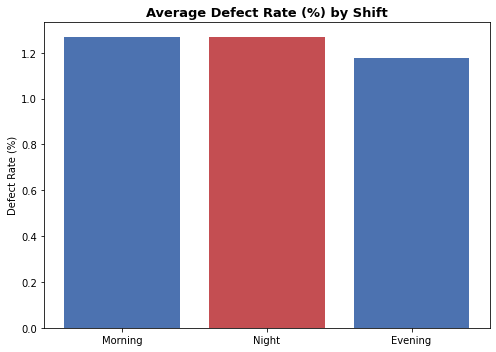

In [ ]:
plt.figure(figsize=(7, 5))
colors = ['#C44E52' if s == 'Night' else '#4C72B0' for s in avg_defect_by_shift.index]
bars = plt.bar(avg_defect_by_shift.index, avg_defect_by_shift.values, color=colors)
plt.title('Average Defect Rate (%) by Shift', fontsize=13, fontweight='bold')
plt.ylabel('Defect Rate (%)')
plt.tight_layout()
plt.show()


### 4.2 Pie Chart — Each shift's share of total defective pieces

In [ ]:
shift_defect_share = df.groupby('Shift')['Defective_Units'].sum()
shift_defect_share

Shift
Evening    1022
Morning    1669
Night       766
Name: Defective_Units, dtype: int64

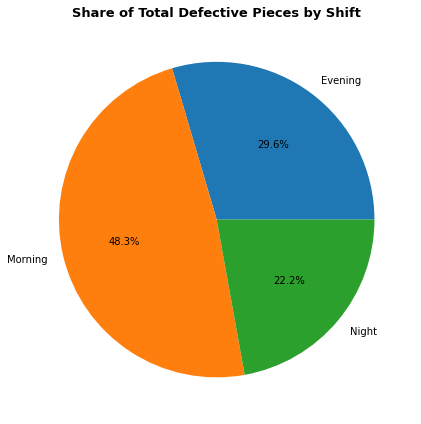

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(shift_defect_share.values, labels=shift_defect_share.index, autopct='%1.1f%%')
plt.title('Share of Total Defective Pieces by Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
shift_volume = df.groupby('Shift').agg(
    Num_Records=('Defective_Units', 'count'),
    Total_Production=('Production_Units', 'sum'),
    Total_Defects=('Defective_Units', 'sum'),
    Avg_Defect_Rate=('Defect_Rate_Percent', 'mean')
)
print(shift_volume)

         Num_Records  Total_Production  Total_Defects  Avg_Defect_Rate
Shift                                                                 
Evening          188           87193.0           1022         1.178637
Morning          277          132028.0           1669         1.269341
Night            135           60626.0            766         1.267362


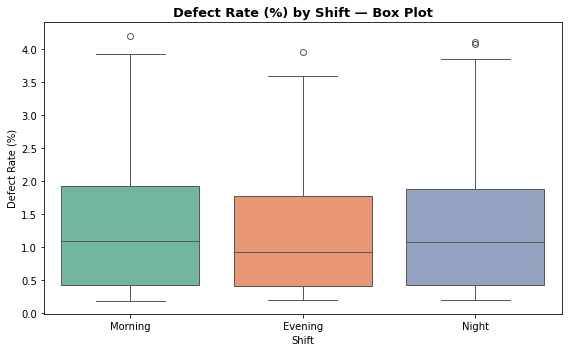

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Shift', y='Defect_Rate_Percent', hue='Shift', palette='Set2', legend=False)
plt.title('Defect Rate (%) by Shift — Box Plot', fontsize=13, fontweight='bold')
plt.ylabel('Defect Rate (%)')
plt.tight_layout()
plt.show()

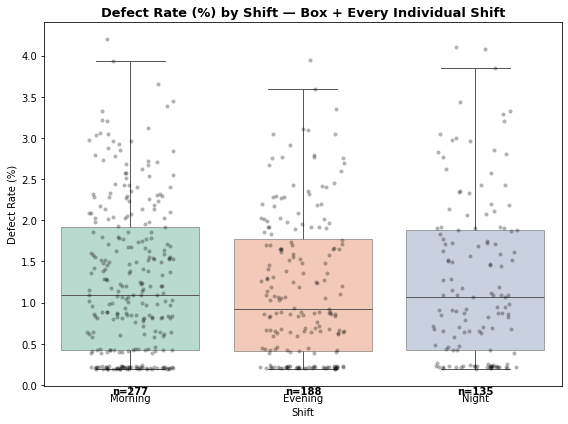

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Shift', y='Defect_Rate_Percent', hue='Shift', palette='Set2', legend=False, showfliers=False, boxprops={'alpha': 0.5})
sns.stripplot(data=df, x='Shift', y='Defect_Rate_Percent', color='black', alpha=0.3, size=4, jitter=0.25)
counts = df.groupby('Shift')['Defect_Rate_Percent'].count()
for i, shift in enumerate(df['Shift'].unique()):
    plt.text(i, df['Defect_Rate_Percent'].min() - 0.3, f"n={counts[shift]}", ha='center', fontsize=10, fontweight='bold')
plt.title('Defect Rate (%) by Shift — Box + Every Individual Shift', fontsize=13, fontweight='bold')
plt.ylabel('Defect Rate (%)')
plt.tight_layout()
plt.show()

### 4.3 Line Chart — Is Night shift *consistently* on top over time?

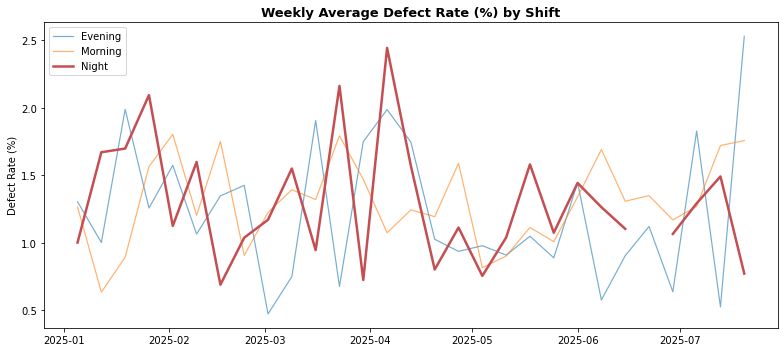

In [ ]:
weekly_by_shift = (df.assign(Date=pd.to_datetime(df['Date'])).set_index('Date').groupby('Shift')['Defect_Rate_Percent'].resample('W').mean().unstack('Shift'))

plt.figure(figsize=(11, 5))
for shift in weekly_by_shift.columns:
    style = dict(linewidth=2.5, color='#C44E52') if shift == 'Night' else dict(linewidth=1.2, alpha=0.6)
    plt.plot(weekly_by_shift.index, weekly_by_shift[shift], label=shift, **style)
plt.title('Weekly Average Defect Rate (%) by Shift', fontsize=13, fontweight='bold')
plt.ylabel('Defect Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()


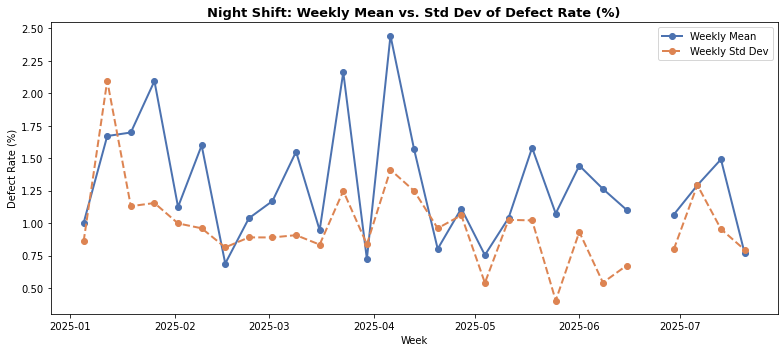

In [ ]:
night_df = df[df['Shift'] == 'Night'].copy()
night_df['Date'] = pd.to_datetime(night_df['Date'])

night_weekly = night_df.set_index('Date')['Defect_Rate_Percent'].resample('W').agg(['mean', 'std'])

plt.figure(figsize=(11, 5))
plt.plot(night_weekly.index, night_weekly['mean'], color='#4C72B0', linewidth=2, marker='o', label='Weekly Mean')
plt.plot(night_weekly.index, night_weekly['std'],  color='#DD8452', linewidth=2, marker='o', linestyle='--', label='Weekly Std Dev')

plt.title('Night Shift: Weekly Mean vs. Std Dev of Defect Rate (%)', fontsize=13, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Defect Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

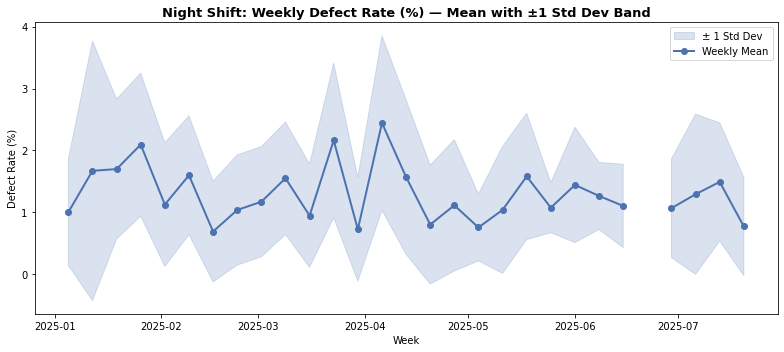

In [ ]:
night_df = df[df['Shift'] == 'Night'].copy()

if 'Date' not in night_df.columns:
    night_df = night_df.reset_index()

night_df['Date'] = pd.to_datetime(night_df['Date'])

night_weekly = night_df.set_index('Date')['Defect_Rate_Percent'].resample('W').agg(['mean', 'std'])

mean_line = night_weekly['mean']
std_band  = night_weekly['std'].fillna(0)   # weeks with only 1 record have NaN std -> treat as 0 width

plt.figure(figsize=(11, 5))

# Shaded band: mean +/- 1 std
plt.fill_between(night_weekly.index, mean_line - std_band, mean_line + std_band,
                  color='#4C72B0', alpha=0.2, label='± 1 Std Dev')

# Mean line on top of the band
plt.plot(night_weekly.index, mean_line, color='#4C72B0', linewidth=2, marker='o', label='Weekly Mean')

plt.title('Night Shift: Weekly Defect Rate (%) — Mean with ±1 Std Dev Band', fontsize=13, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Defect Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(night_weekly[night_weekly['mean'].isna()])

print(night_df.set_index('Date').resample('W').size().loc['2025-06-15':'2025-07-15'])

            mean  std
Date                 
2025-06-22   NaN  NaN
Date
2025-06-15    6
2025-06-22    0
2025-06-29    7
2025-07-06    6
2025-07-13    6
Freq: W-SUN, dtype: int64


## 🧾 Section 5: What Do the Graphs Tell Us?

Before running any formal test, read the visuals like an analyst would:

- **Bar chart (4.1):** Is Night's bar clearly the tallest, or are all three shifts close together?
- **Pie chart (4.2):** Does Night's slice look noticeably bigger than a fair 1/3 share?
- **Line chart (4.3):** Does the Night line sit *consistently* above the others week after week, or does it only win in a few weeks and lose in others (a sign of noise, not a real pattern)?


## 🔁 Section 6: Your Turn — A Second Hypothesis

**Hypothesis 2:** *"Higher shop-floor temperature leads to more defective pieces."*

This is a different *kind* of hypothesis — not comparing groups (like Night vs. other shifts), but testing whether two **continuous numeric variables** move together. That means a slightly different toolkit:

1. **Visualize it first:** make a scatter plot of `Temperature_C` (x-axis) vs `Defective_Units` (y-axis). Does it look like an upward trend?
2. **Compute the correlation:** use `.corr()` — is it positive, negative, or near zero? How strong?
3. **Validate it** using plots
4. **Conclude:** write 1-2 sentences — is this hypothesis supported?

Try it below — the cells are intentionally left blank for you.

In [ ]:
# Step 1: Scatter plot of Temperature_C vs Defective_Units



In [ ]:
# Step 2 and 3 : Correlation between Temperature_C and Defective_Units



_Step 4: Your written conclusion (double-click to edit)._


---
## 📝 Assignment — Try It Yourself! (15 Questions)

### Loading & Missing Data
1. Load the dataset and print its shape and the first 5 rows.
2. Compute the missing value count and percentage for every column. Which column(s) need imputation before we can fairly compare shifts?
3. Impute missing values in `Shift` (mode), `Temperature_C` (mean), and `Operator_Experience_Years` (median). In one sentence each, explain why you chose mean vs. median for the two numeric columns.

### Descriptive Statistics
4. Compute the mean, median, and mode of `Defective_Units`. Which measure best represents a "typical" shift, and why?
5. Compute the standard deviation and IQR of `Defective_Units` for each `Shift`. Which shift is the most *inconsistent* (highest spread), and is that the same shift with the highest average?
6. Compute the correlation and covariance between `Temperature_C` and `Defective_Units`. Interpret the relationship in one sentence.

### Visualization Supporting the Hypothesis
7. Create a bar chart comparing the average `Defect_Rate_Percent` across the three shifts.
8. Create a pie chart showing each shift's share of total `Defective_Units`.
9. Create a line chart showing the weekly trend of `Defective_Units` for the Night shift only, compared against the other two shifts on the same plot. Does Night stay consistently on top, or does it cross over?
10. Create a box plot comparing `Defect_Rate_Percent` across shifts. What does the spread tell you that the bar chart in Q7 didn't?

### Reading the Evidence and report
11. Based on your answers to Q7–Q10, write 2–3 sentences: does the visual evidence support "Night shift has a higher defect rate"? Be specific about which chart convinced you (or didn't).


In [ ]:
# Q1: Your code here



In [ ]:
# Q2: Your code here



In [ ]:
# Q3: Your code here



In [ ]:
# Q4: Your code here



In [ ]:
# Q5: Your code here



In [ ]:
# Q6: Your code here



In [ ]:
# Q7: Your code here



In [ ]:
# Q8: Your code here



In [ ]:
# Q9: Your code here



In [ ]:
# Q10: Your code here



In [ ]:
# Q11: Your code here



In [ ]:
# Q12: Your code here



In [ ]:
# Q13: Your code here



In [ ]:
# Q14: Your code here



In [ ]:
# Q15: Your code here



### Your Written Conclusions

_Write your answers to Q11 and Q15 here (double-click to edit)._
